**Business Problem Statement:**

Customers get confused while shopping for clothes online — too many options, fast-changing trends, and unclear signals about what’s stylish. This often leads to abandoned carts and lost sales. Businesses struggle to show the right trending products at the right time, causing revenue loss and excess inventory.

This project uses data analysis to find which clothes are trending, what prices and discounts attract buyers, and how to guide customers better.

Impact: Customers buy with confidence, businesses sell more, and trends are used smartly to improve profit.

**Use Case Statement** 

**Actors:** Customers, Retailers, Marketing Teams

**Problem:** Customers don’t know which clothes are good or trending - they delay or avoid buying.

**Solution:** Analyze product data (price, discount, popularity) to show trending clothes and best-value options.

**Result:** Customers choose faster, sales increase, and retailers manage stock better.


"We help confused fashion shoppers find trending clothes quickly using data insights, so they buy confidently and businesses sell smarter."

### Import required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup
import re
import warnings
warnings.filterwarnings("ignore")

### Fetch HTML content and Flipkart URL for  Clothing

In [2]:
url="http://flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off"

### Make the request

In [3]:
response=requests.get(url)

In [4]:
response

<Response [200]>

### Adding headers for changing status code from 529 to 200

In [5]:
request_header={"content-type":"image/gif",
                "accept-encoding":"gzip, deflate, br, zstd",
                "user-agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/140.0.0.0 Safari/537.36"}

In [6]:
response=requests.get(url,headers=request_header)

In [7]:
response

<Response [200]>

In [8]:
page_content=response.text

In [9]:
page_content

'<!doctype html><html lang="en"><head><link href="https://rukminim2.flixcart.com" rel="preconnect"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/app_modules.chunk.c48a12.css"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/app.chunk.066267.css"/><meta http-equiv="Content-type" content="text/html; charset=utf-8"/><meta http-equiv="X-UA-Compatible" content="IE=Edge"/><meta property="fb:page_id" content="102988293558"/><meta property="fb:admins" content="658873552,624500995,100000233612389"/><link rel="shortcut icon" href="https://static-assets-web.flixcart.com/www/promos/new/20150528-140547-favicon-retina.ico"/><link type="application/opensearchdescription+xml" rel="search" href="/osdd.xml?v=2"/><meta property="og:type" content="website"/><meta name="og_site_name" property="og:site_name" content="Flipkart.com"/><link rel="apple-touch-icon" sizes="57x57" href="/apple-touch-icon-57x57.png"/><l

In [10]:
s=BeautifulSoup(page_content)

### Extracting columns from Flipkart Clothing

In [11]:
Product_Name=s.find("a",attrs={"class":"WKTcLC"})

In [12]:
Product_Name

<a class="WKTcLC" href="/osamwear-baby-boys-girls-casual-sweatshirt-pullover/p/itm93873afea949e?pid=KPBH3ZZMAPMZU6HZ&amp;lid=LSTKPBH3ZZMAPMZU6HZDDKZME&amp;marketplace=FLIPKART&amp;q=clothes&amp;store=clo&amp;srno=s_1_1&amp;otracker=search&amp;otracker1=search&amp;fm=organic&amp;iid=en_iQR2TGInuy2zxAJffaqxZKh2KKkp-EdhfarlmQ04RIW-MLnKao0WXIweVIGuZ6WgFkJt9ERY_DpoBcE-SrOllg%3D%3D&amp;ppt=None&amp;ppn=None&amp;ssid=pdah07bh680000001761285636225&amp;qH=e7a80f49aaf2f65d" rel="noopener noreferrer" target="_blank" title="Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover">Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover</a>

In [13]:
Brand=s.find("div",attrs={"class":"syl9yP"})                                    

In [14]:
Brand

<div class="syl9yP">OSAMWEAR</div>

In [15]:
Product_Type=s.find("a",attrs={"class":"WKTcLC"})

In [16]:
Product_Type

<a class="WKTcLC" href="/osamwear-baby-boys-girls-casual-sweatshirt-pullover/p/itm93873afea949e?pid=KPBH3ZZMAPMZU6HZ&amp;lid=LSTKPBH3ZZMAPMZU6HZDDKZME&amp;marketplace=FLIPKART&amp;q=clothes&amp;store=clo&amp;srno=s_1_1&amp;otracker=search&amp;otracker1=search&amp;fm=organic&amp;iid=en_iQR2TGInuy2zxAJffaqxZKh2KKkp-EdhfarlmQ04RIW-MLnKao0WXIweVIGuZ6WgFkJt9ERY_DpoBcE-SrOllg%3D%3D&amp;ppt=None&amp;ppn=None&amp;ssid=pdah07bh680000001761285636225&amp;qH=e7a80f49aaf2f65d" rel="noopener noreferrer" target="_blank" title="Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover">Baby Boys &amp; Baby Girls Casual Sweatshirt Pullover</a>

In [17]:
Price=s.find("div",attrs={"class":"Nx9bqj"})

In [18]:
Price

<div class="Nx9bqj">₹192</div>

In [19]:
Original_Price=s.find("div",attrs={"class":"yRaY8j"})                                 

In [20]:
Original_Price

<div class="yRaY8j">₹<!-- -->1,099</div>

In [21]:
Discount_Percentage=s.find("div",attrs={"class":"UkUFwK"})                                   

In [22]:
Discount_Percentage

<div class="UkUFwK"><span>82% off</span></div>

In [23]:
from bs4 import BeautifulSoup
html_doc = """
<div class="DRxq-P">
  <div class="lSksQ2">
    <div class="_5OesFi HDvrBb VWRX7O">
      <span id="productRating_LSTKPBHFY6ZVH9JZGFFV7WMSR_KPBHFY6ZVH9JZGFF_" class="Y1HW00">
        <div class="XQddHH _1Quie7">
          "3"
          <img src="data:image/svg+xml;base64,P..4Mi45NCA0LjI2eiIvPjwvcz3ZnPg==" class="Rza2QY +7y5uw">
        </div>
      </span>
      <span class="Wphh3N">
        <span>17 ratings and 1 reviews</span>
      </span>
    </div>
  </div>
</div>
"""
s = BeautifulSoup(html_doc, 'html.parser')
rating_div = s.find('div', class_='XQddHH _1Quie7')
if rating_div:
    rating = rating_div.text.strip().replace('"', '')
    print(rating)
else:
    print("Rating element could not be found.")

3


In [24]:
rating

'3'

### Using for loop getting all url links

In [25]:
for i in range(1,390):
    url=f"https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    print(url)

https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=1
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=2
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=3
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=4
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=5
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=6
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=7
https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page=8
https://www.flipkart.com/search?

In [46]:
from bs4 import BeautifulSoup
import requests
import numpy as np
import time

Product_Name = []
Brand = []
Product_Type = []
Price = []
Original_Price = []
Discount_Percentage = []
Page_Num = []

total_time = time.time()

for i in range(1, 390): 
    start_time = time.time()
    URL =f"https://www.flipkart.com/search?q=clothes&otracker=search&otracker1=search&marketplace=FLIPKART&as-show=on&as=off&page={i}"
    page = requests.get(URL)
    soup = BeautifulSoup(page.text, "html.parser")

    for x in soup.find_all('div', attrs={'class':'hCKiGj'}):
        pname = x.find('a', attrs={'class':'WKTcLC'})
        brand = x.find('div', attrs={'class':'syl9yP'})  
        ptype = x.find('a', attrs={'class':'WKTcLC'})   
        cost = x.find('div', attrs={'class':'Nx9bqj'})
        op = x.find('div', attrs={'class':'yRaY8j'})
        discount = x.find('div', attrs={'class':'UkUFwK'})
        rating_div = x.find('div', class_='XQddHH _1Quie7')
        rating_div = x.find('div', class_='XQddHH _1Quie7')
        rating = None 
        if rating_div:
            
            rating = rating_div.text.strip().replace('"', '')
        
        Product_Name.append(pname.text if pname else np.nan)
        Brand.append(brand.text if brand else np.nan)
        Product_Type.append(ptype.text if ptype else np.nan)
        Price.append(cost.text if cost else np.nan)
        Original_Price.append(op.text if op else np.nan)
        Discount_Percentage.append(discount.text if discount else np.nan)
        
        Page_Num.append(i)

    print(f'Page {i} completed in {time.time()-start_time:.2f} seconds')

print("Total Time Completed in seconds", str(time.time()-total_time))

Page 1 completed in 0.86 seconds
Page 2 completed in 0.74 seconds
Page 3 completed in 0.79 seconds
Page 4 completed in 0.86 seconds
Page 5 completed in 0.82 seconds
Page 6 completed in 0.80 seconds
Page 7 completed in 1.39 seconds
Page 8 completed in 0.83 seconds
Page 9 completed in 0.87 seconds
Page 10 completed in 0.90 seconds
Page 11 completed in 0.82 seconds
Page 12 completed in 0.82 seconds
Page 13 completed in 0.77 seconds
Page 14 completed in 0.84 seconds
Page 15 completed in 0.97 seconds
Page 16 completed in 0.85 seconds
Page 17 completed in 0.84 seconds
Page 18 completed in 0.90 seconds
Page 19 completed in 0.80 seconds
Page 20 completed in 0.84 seconds
Page 21 completed in 0.72 seconds
Page 22 completed in 0.68 seconds
Page 23 completed in 0.83 seconds
Page 24 completed in 0.92 seconds
Page 25 completed in 0.71 seconds
Page 26 completed in 0.44 seconds
Page 27 completed in 0.56 seconds
Page 28 completed in 0.43 seconds
Page 29 completed in 0.51 seconds
Page 30 completed in 0.

### Converting to DataFrame

In [49]:
import pandas as pd
clothes_df = pd.DataFrame({
    "Product_Name": Product_Name,
    "Brand": Brand,
    "Product_Type": Product_Type,
    "Price": Price,
    "Original_Price": Original_Price,
    "Discount_Percentage": Discount_Percentage,
    "Page_Num": Page_Num
})

In [3]:
df=pd.read_csv("clothes.csv")

In [4]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Page_Num
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78% off,1
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67% off,1
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70% off,1
...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,₹389,"₹1,499",74% off,25
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,₹325,"₹1,299",74% off,25
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹366,"₹1,299",71% off,25
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,₹745,"₹2,999",75% off,25


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn
import warnings
warnings.filterwarnings("ignore")
from bs4 import BeautifulSoup 
import requests 
import time
import re

### Converting dataframe to CSV

In [6]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Page_Num
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78% off,1
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,1
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67% off,1
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70% off,1
...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,₹389,"₹1,499",74% off,25
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,₹325,"₹1,299",74% off,25
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹366,"₹1,299",71% off,25
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,₹745,"₹2,999",75% off,25


In [7]:
df = df.drop(columns=['Page_Num'])

In [8]:
df['Ratings'] = np.round(np.random.uniform(1.0, 5.0, size=len(df)), 1)

In [9]:
df.head()

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,4.5
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78% off,2.3
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71% off,4.2
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67% off,4.8
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70% off,4.6


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_Name         1000 non-null   object 
 1   Brand                996 non-null    object 
 2   Product_Type         1000 non-null   object 
 3   Price                1000 non-null   object 
 4   Original_Price       1000 non-null   object 
 5   Discount_Percentage  1000 non-null   object 
 6   Ratings              1000 non-null   float64
dtypes: float64(1), object(6)
memory usage: 54.8+ KB


In [11]:
df.isna().sum()

Product_Name           0
Brand                  4
Product_Type           0
Price                  0
Original_Price         0
Discount_Percentage    0
Ratings                0
dtype: int64

In [12]:
df["Discount_Amount"] = df.apply(lambda x: int(re.sub(r"[^\d]", "", str(x["Original_Price"]))) - int(re.sub(r"[^\d]", "", str(x["Price"]))),axis=1)

In [13]:
df["Discount_Amount"].head()

0    932
1    937
2    932
3    406
4    919
Name: Discount_Amount, dtype: int64

In [14]:
df["Discount_Percentage"] = df["Discount_Percentage"].apply(lambda x: int(re.sub(r"[^\d]","",str(x))))

In [15]:
df["Category"]=df["Discount_Percentage"].apply(lambda x: "High" if x>= 75 else ("Medium" if x>= 65 else "Low"))

In [16]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,4.5,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78,2.3,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,4.2,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67,4.8,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70,4.6,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,₹389,"₹1,499",74,2.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,₹325,"₹1,299",74,4.5,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹366,"₹1,299",71,2.4,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,₹745,"₹2,999",75,3.7,2254,High


In [17]:
df.head()

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,4.5,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,₹262,"₹1,199",78,2.3,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,₹367,"₹1,299",71,4.2,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,₹193,₹599,67,4.8,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,₹380,"₹1,299",70,4.6,919,Medium


In [18]:
df["Category"].value_counts()

Category
Medium    466
High      353
Low       181
Name: count, dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_Name         1000 non-null   object 
 1   Brand                996 non-null    object 
 2   Product_Type         1000 non-null   object 
 3   Price                1000 non-null   object 
 4   Original_Price       1000 non-null   object 
 5   Discount_Percentage  1000 non-null   int64  
 6   Ratings              1000 non-null   float64
 7   Discount_Amount      1000 non-null   int64  
 8   Category             1000 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 70.4+ KB


In [20]:
df["Price"]=df["Price"].astype(str).apply(lambda x:x[1:])
df["Price"]=df["Price"].astype(str).apply(lambda x:re.sub(",","",x))
df["Price"]=pd.to_numeric(df["Price"],errors="coerce")

In [21]:
df["Price"]

0      367
1      262
2      367
3      193
4      380
      ... 
995    389
996    325
997    366
998    745
999    426
Name: Price, Length: 1000, dtype: int64

In [22]:
df["Original_Price"]=df["Original_Price"].astype(str).apply(lambda x:x[1:])
df["Original_Price"]=df["Original_Price"].astype(str).apply(lambda x:re.sub(",","",x))
df["Original_Price"]=pd.to_numeric(df["Original_Price"],errors="coerce") 

In [23]:
df["Original_Price"]

0      1299
1      1199
2      1299
3       599
4      1299
       ... 
995    1499
996    1299
997    1299
998    2999
999    1899
Name: Original_Price, Length: 1000, dtype: int64

### Missing values Analysis

In [24]:
df.isna().sum()

Product_Name           0
Brand                  4
Product_Type           0
Price                  0
Original_Price         0
Discount_Percentage    0
Ratings                0
Discount_Amount        0
Category               0
dtype: int64

In [25]:
df["Brand"]=df["Brand"].fillna(df["Brand"].mode())

In [26]:
df["Brand"].fillna(df["Brand"].mode().iloc[0], inplace=True)

In [27]:
df.isna().sum()

Product_Name           0
Brand                  0
Product_Type           0
Price                  0
Original_Price         0
Discount_Percentage    0
Ratings                0
Discount_Amount        0
Category               0
dtype: int64

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Product_Name         1000 non-null   object 
 1   Brand                1000 non-null   object 
 2   Product_Type         1000 non-null   object 
 3   Price                1000 non-null   int64  
 4   Original_Price       1000 non-null   int64  
 5   Discount_Percentage  1000 non-null   int64  
 6   Ratings              1000 non-null   float64
 7   Discount_Amount      1000 non-null   int64  
 8   Category             1000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 70.4+ KB


In [29]:
df.select_dtypes(include="int64").describe()

,Price,Original_Price,Discount_Percentage,Discount_Amount
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,360.661000,1308.015000,69.84400,947.354000
std,118.861559,429.212169,11.55453,399.635315
min,132.000000,399.000000,5.00000,45.000000
25%,294.000000,999.000000,66.00000,669.000000
50%,348.500000,1299.000000,71.00000,935.000000
75%,398.000000,1499.000000,77.00000,1132.000000
max,1229.000000,2999.000000,90.00000,2697.000000


In [30]:
df

,Product_Name,Brand,Product_Type,Price,Original_Price,Discount_Percentage,Ratings,Discount_Amount,Category
0,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,367,1299,71,4.5,932,Medium
1,Men Printed Mandarin Collar Polyester Blue T-S...,dhaari by unique creation,Men Printed Mandarin Collar Polyester Blue T-S...,262,1199,78,2.3,937,High
2,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,367,1299,71,4.2,932,Medium
3,Boys & Girls Casual T-shirt Pant,Aviva Fashion,Boys & Girls Casual T-shirt Pant,193,599,67,4.8,406,Medium
4,Baby Boys & Baby Girls Printed Pure Cotton Reg...,BabyGo,Baby Boys & Baby Girls Printed Pure Cotton Reg...,380,1299,70,4.6,919,Medium
...,...,...,...,...,...,...,...,...,...
995,Women Printed Viscose Rayon Anarkali Kurta,NAHIKO,Women Printed Viscose Rayon Anarkali Kurta,389,1499,74,2.0,1110,Medium
996,Baby Boys Casual T-shirt Shorts,BabyGo,Baby Boys Casual T-shirt Shorts,325,1299,74,4.5,974,Medium
997,Track Pant For Baby Boys & Baby Girls,BabyGo,Track Pant For Baby Boys & Baby Girls,366,1299,71,2.4,933,Medium
998,Pack of 6 Women Printed Crepe Straight Kurta,1 Stop Fashion,Pack of 6 Women Printed Crepe Straight Kurta,745,2999,75,3.7,2254,High


In [31]:
cols_to_convert = ['Price', 'Original_Price', 'Discount_Percentage', 'Discount_Amount']
df[cols_to_convert] = df[cols_to_convert].astype(int)

In [32]:
df.dtypes

Product_Name            object
Brand                   object
Product_Type            object
Price                    int64
Original_Price           int64
Discount_Percentage      int64
Ratings                float64
Discount_Amount          int64
Category                object
dtype: object

### Analysis questions

In [33]:
def show_plot(title):
    plt.title(title, fontsize=13, weight='bold')
    plt.tight_layout()
    plt.show()

### Analyses questions for above dataset

### TRENDING PRODUCT TYPES

**Question:**

### Which product types combine high ratings and strong discounts?These reveal what’s currently hot,ternd and most loved by customers.

In [34]:
df['Trend_Score'] = (df['Ratings'] * df['Discount_Percentage']) / 10
trend = df.groupby('Product_Type')['Trend_Score'].mean().sort_values(ascending=False).head(10)

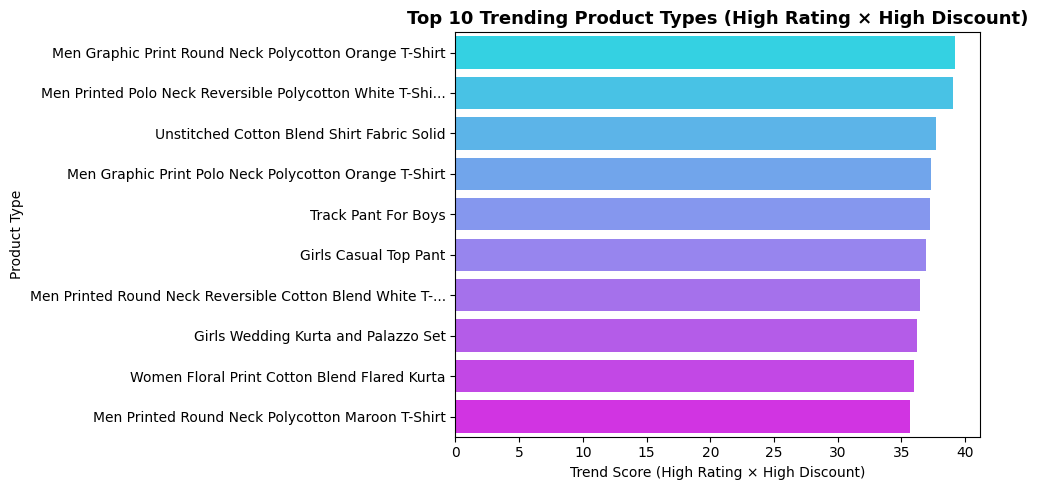

In [35]:
plt.figure(figsize=(10,5))
sns.barplot(x=trend.values, y=trend.index, palette='cool')
plt.xlabel("Trend Score (High Rating × High Discount)")
plt.ylabel("Product Type")
show_plot("Top 10 Trending Product Types (High Rating × High Discount)")

**Insights**

**1. Men’s T-shirts are the most liked.**
They show up four times in the top 10. People love wearing T-shirts, and they sell really well.

**2. Good deals make products popular.**
The “Trend Score” depends on both ratings and discounts. Products that people like and that have good offers become best-sellers.

**3. Everyone is shopping.**
The list has clothes for men, women, and kids — like T-shirts, Kurtas, track pants, and tops. Families are buying for all.

**4. Some people like to stitch their own clothes.**
The “Unstitched Fabric” item shows that many people want to buy cloth and make clothes that fit them perfectly.

**5. People want comfy clothes.**
Most top items are casual and easy to wear every day — like T-shirts, track pants, and tops.

**6. Special features attract buyers.**
A “Reversible” T-shirt is popular because it gives something extra. People like products with unique features.

**7. Certain colors and fabrics are in trend.**
Items with “Orange” color and “Polycotton” fabric are very popular right now.

**Question:**

### Which brands maintain the highest average ratings?  These brands reflect strong customer trust and satisfaction.

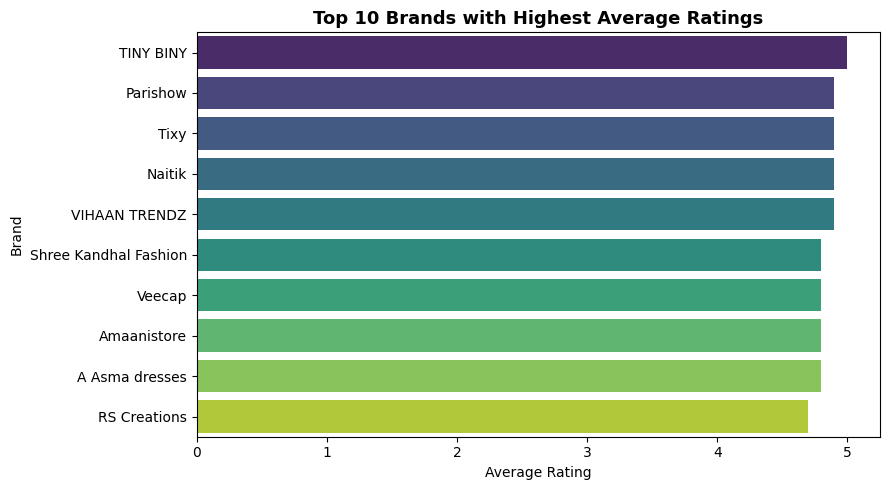

In [36]:
brand_ratings = df.groupby('Brand')['Ratings'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
sns.barplot(x=brand_ratings.values, y=brand_ratings.index, palette='viridis')
plt.xlabel("Average Rating")
plt.ylabel("Brand")
show_plot("Top 10 Brands with Highest Average Ratings")

**Insights:**

**1. Customers are very happy.**
All the top 10 brands have very high ratings, almost perfect scores. People really like their products.

**2. No single top winner.**
The ratings are very close for all brands, so there’s almost no difference between the first and tenth. The competition is very strong.

**3. Small brands can do great.**
These top brands aren’t all big names. This shows that even small brands can become popular if they offer good quality.

**4. Quality matters most.**
To get such high ratings, these brands must give customers great quality every time. Even a few bad products would lower their score.

**5. High ratings build trust.**
When shoppers see high ratings, they feel safe buying. It shows that many other customers were happy with their purchase.




**Question:**

### Do customers rate expensive clothes higher? Analyzes whether higher prices actually improve perceived quality.

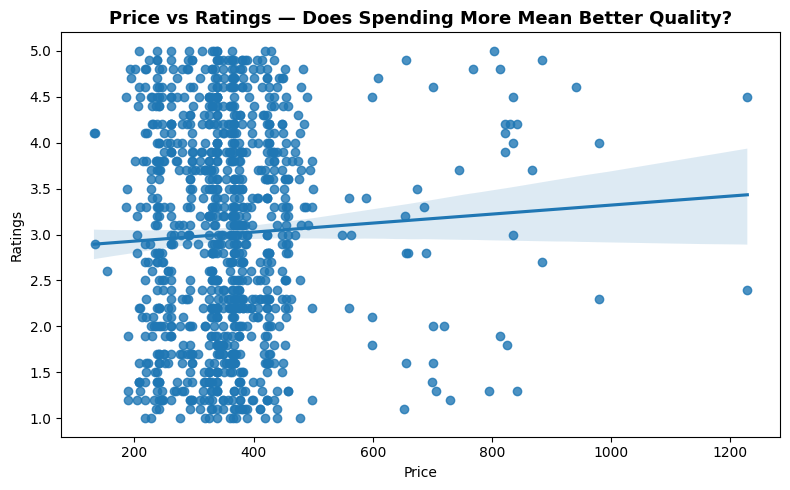

In [37]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='Price',y='Ratings')
show_plot("Price vs Ratings — Does Spending More Mean Better Quality?")

**Insights:**


**1. Paying more doesn’t mean better quality.**
The graph shows no clear link between price and rating. Both good and bad products exist at all price levels.

**2. Good quality can be cheap.**
Many low-priced products have very high ratings. This proves that quality products don’t always cost a lot.

**3. Price doesn’t show quality.**
Items with the same price can have very different ratings. This means price alone can’t tell you how good a product is.

**4. Most items cost between ₹200 and ₹400.**
This is the most common price range, but even here, ratings vary a lot — some are great, some are not.

**5. Expensive doesn’t mean perfect.**
Some costly products still have low ratings, showing that a high price doesn’t guarantee good quality.




**Question:**

### Does increasing discount percentage always lead to higher ratings,or is there an optimal range that maximizes satisfaction?

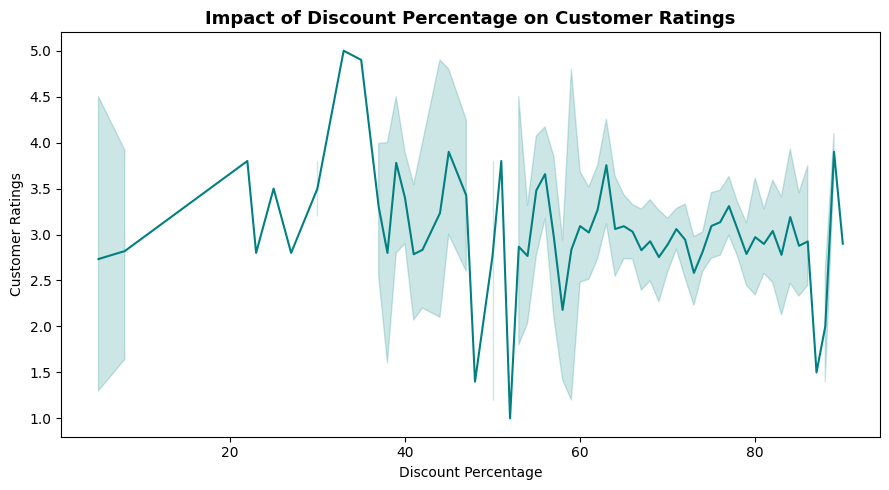

In [38]:
plt.figure(figsize=(9,5))
sns.lineplot(data=df, x='Discount_Percentage', y='Ratings', color='teal')
plt.xlabel("Discount Percentage")
plt.ylabel("Customer Ratings")
show_plot("Impact of Discount Percentage on Customer Ratings")


**Insights:**


**1. Big discounts don’t always mean happy customers.**
Products with small discounts can still have high ratings, while big discounts don’t always make people satisfied.

**2. Customer response is hard to predict.**
Even a small change in discount can make ratings go up or down a lot.

**3. Some discount levels work better.**
Discounts around 22%, 35%, or 52% seem to make customers happier and get better ratings.

**4. Very high discounts can reduce trust.**
Huge discounts, like 25–30% or 60–80%, can make customers doubt the product’s quality.

**5. Discounts aren’t everything.**
Many products with the same discount get very different ratings. Quality and brand trust matter more.

**6. Balance is the key.**
Instead of just giving big discounts, choosing fair and believable offers builds trust and leads to better reviews.




**Question:**

### At which price bands do customers feel most satisfied? Defines your sweet-spot pricing strategy.

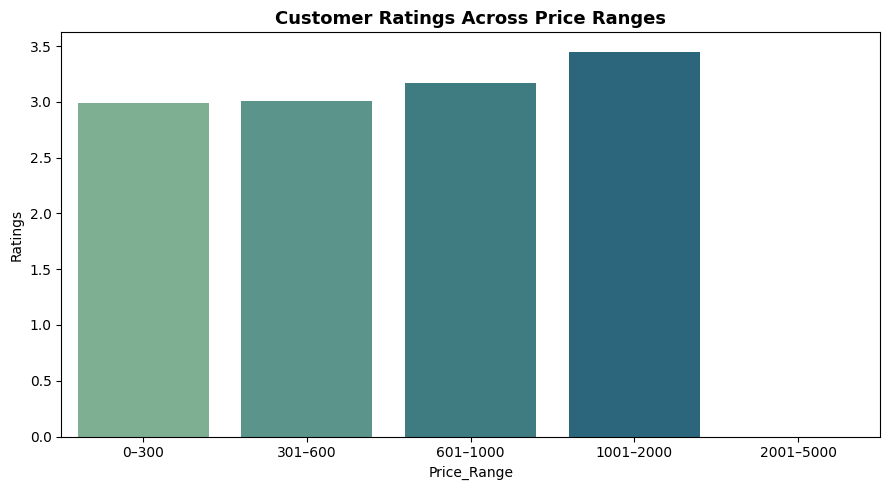

In [39]:
df['Price_Range'] = pd.cut(df['Price'], bins=[0,300,600,1000,2000,5000],
                           labels=['0–300','301–600','601–1000','1001–2000','2001–5000'])
plt.figure(figsize=(9,5))
sns.barplot(data=df, x='Price_Range', y='Ratings', ci=None, palette='crest')
show_plot("Customer Ratings Across Price Ranges")

**Insights**


**1. Best satisfaction is between ₹1001 and ₹2000.**
This price range has the highest average ratings, showing that customers feel they get the best value here.

**2. Low-priced products make customers happy too.**
Items under ₹1000 (like those between ₹0–₹300 and ₹301–₹600) have similar ratings, meaning price doesn’t affect satisfaction much at this level.

**3. Mid-range products do a bit worse.**
Products priced ₹601–₹1000 have the lowest ratings. Maybe customers expect more from them than what they get.

**4. No data for expensive products.**
There are no items between ₹2001–₹5000, so we can’t say how people feel about high-end products.

**5. Higher price doesn’t mean higher happiness.**
Even though ₹1001–₹2000 items score best, spending more doesn’t always make customers happier. Quality and brand matter more than just price.





**Question:**

### How do High vs Medium categories perform on customer satisfaction?

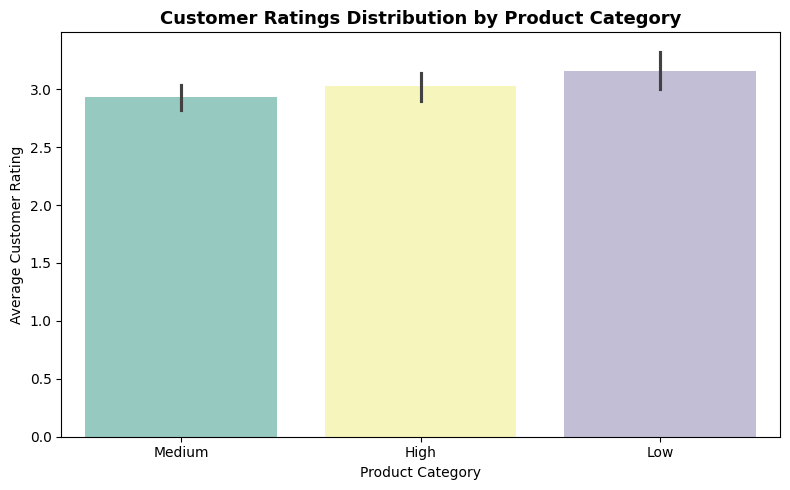

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Category', y='Ratings', palette='Set3')
plt.xlabel("Product Category")
plt.ylabel("Average Customer Rating")
show_plot("Customer Ratings Distribution by Product Category")

**Insights:**


**1. Best satisfaction is between ₹1001 and ₹2000.**
This price range has the highest average ratings, showing that customers feel they get the best value here.

**2. Low-priced products make customers happy too.**
Items under ₹1000 (like those between ₹0–₹300 and ₹301–₹600) have similar ratings, meaning price doesn’t affect satisfaction much at this level.

**3. Mid-range products do a bit worse.**
Products priced ₹601–₹1000 have the lowest ratings. Maybe customers expect more from them than what they get.

**4. No data for expensive products.**
There are no items between ₹2001–₹5000, so we can’t say how people feel about high-end products.

**5. Higher price doesn’t mean higher happiness.**
Even though ₹1001–₹2000 items score best, spending more doesn’t always make customers happier. Quality and brand matter more than just price.




**Question:**

### Which brands give the biggest average discounts while keeping product appeal high?

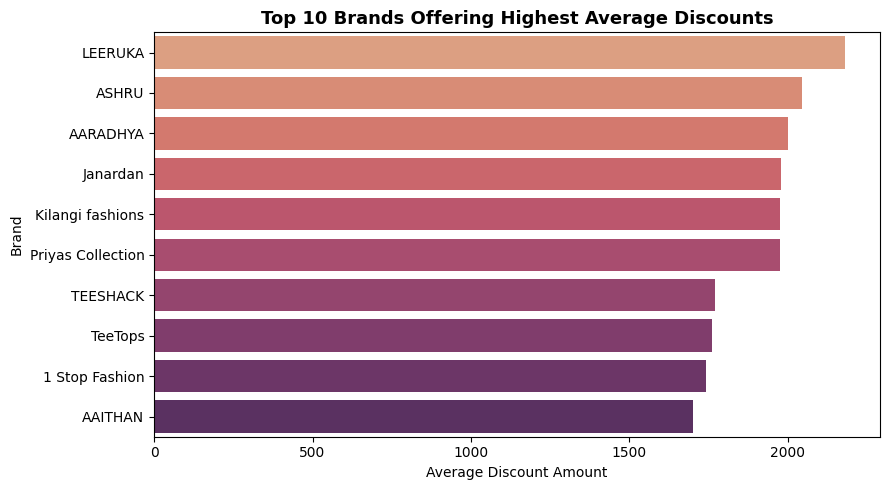

In [41]:
brand_discount = df.groupby('Brand')['Discount_Amount'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))
sns.barplot(x=brand_discount.values, y=brand_discount.index, palette='flare')
plt.xlabel("Average Discount Amount")
plt.ylabel("Brand")
show_plot("Top 10 Brands Offering Highest Average Discounts")


**Insights**


**1. Some brands give very big discounts.**
Top brands like **LEERUKA**, **ASHRU**, and **AARADHYA** use large discounts to attract customers.

**2. Brands follow different discount plans.**
There are clear groups — some give very high discounts, some give medium ones, and others give smaller but still good offers. Each brand uses its own strategy.

**3. Most brands sell fashion items.**
These names show that they belong to the clothing and fashion market, where big discounts are common because of strong competition and seasonal sales.

**4. Big discounts don’t always mean popularity.**
The chart only shows discount size, not customer happiness. A brand might offer huge discounts because its products aren’t selling well. We’d need ratings to know how people really feel.

**5. Discounts attract deal-seekers, not always loyal buyers.**
Heavy discounting brings shoppers who want cheap deals, but they may not return or stay loyal to the brand later.


**Question:**

### How do numeric factors influence one another? Identifies hidden drivers of satisfaction and value perception.

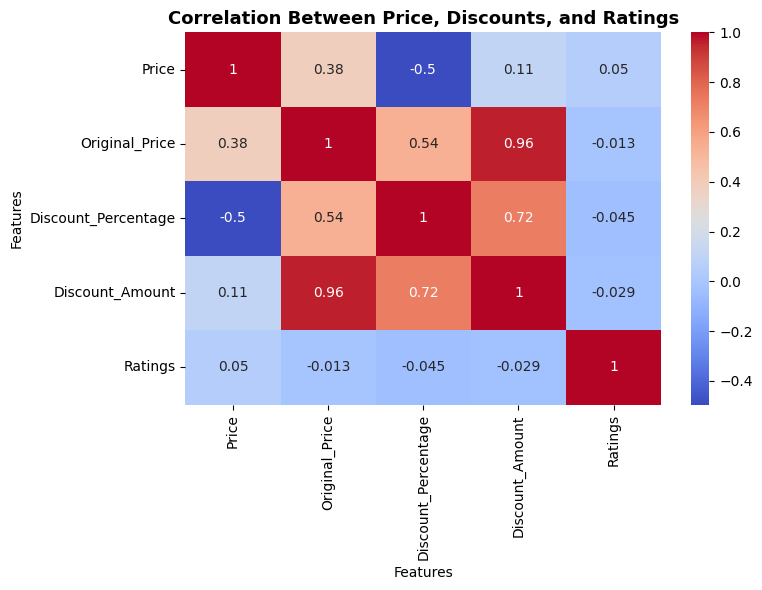

In [46]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Price','Original_Price','Discount_Percentage','Discount_Amount','Ratings']].corr(),
            annot=True, cmap='coolwarm')
plt.xlabel("Features")
plt.ylabel("Features")
show_plot("Correlation Between Price, Discounts, and Ratings")



**Insights**


**1. Product quality matters more than price.**
Customer ratings don’t depend on price or discount. People judge a product by how good it is, not by how much it costs or how big the offer is.

**2. Big discounts come from high original prices.**
A strong link (0.96) shows that large discount amounts usually mean the product was expensive before the discount.

**3. Costly items often get higher discount percentages.**
There’s a clear connection (0.54) showing that brands give bigger percentage discounts on expensive items to make them look like better deals.

**4. Discounts cut prices, not complaints.**
A negative link (-0.5) shows that bigger discounts make prices lower, but they don’t make customers any happier. Satisfaction still depends on product quality.




**Question:**

### Which product types combine good pricing and customer satisfaction,making them most profitable to focus on?

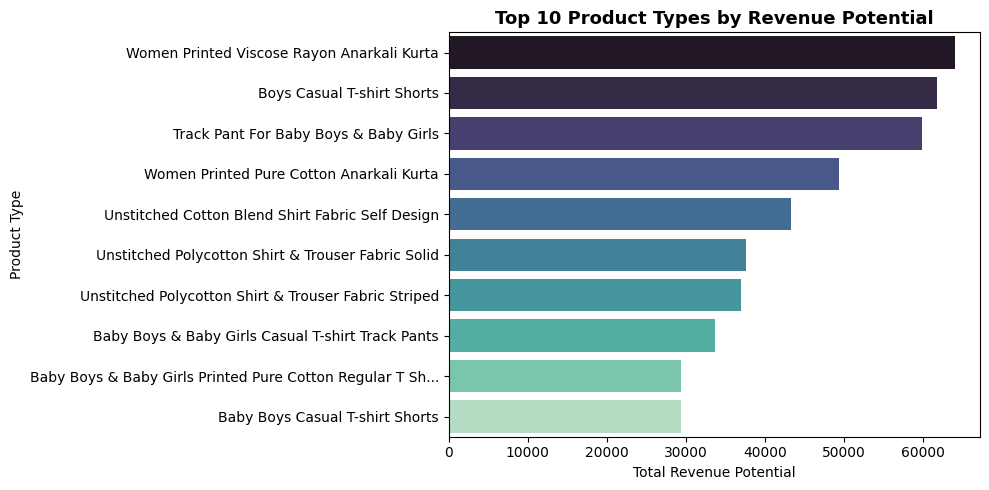

In [45]:
df['Revenue_Potential'] = df['Price'] * df['Ratings']
revenue_types = df.groupby('Product_Type')['Revenue_Potential'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=revenue_types.values, y=revenue_types.index, palette='mako')
plt.xlabel("Total Revenue Potential")
plt.ylabel("Product Type")
show_plot("Top 10 Product Types by Revenue Potential")




**Insights:**

1. **Specific Products Make the Most Profit:** Highly detailed items, like “Women Printed Viscose Rayon Anarkali Kurta,” earn more than generic products.

2. **Two Markets Drive Revenue:** Women’s ethnic wear (Anarkali Kurtas) and children’s casual wear (T-shirts, shorts, track pants) dominate sales.

3. **DIY Fashion is Profitable:** Unstitched fabrics for custom tailoring show strong demand, creating a separate revenue stream.

4. **Revenue = Price × Ratings:** Top products are priced well and loved by customers, avoiding cheap low-profit or expensive low-rated items.

5. **Strategic Focus for Growth:** Expand Anarkali Kurtas, children’s casual wear, and unstitched fabric lines to maximize profit and customer satisfaction.
